In [ ]:
import psutil

ram = psutil.virtual_memory()
print(f"Total RAM: {ram.total / (1024**3):.2f} GB")
print(f"Available RAM: {ram.available / (1024**3):.2f} GB")

Total RAM: 172.95 GB
Available RAM: 169.83 GB


In [ ]:


# install requirements for v6 Tpu
!pip install opencv-python
!pip install tensorflow
!pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 132.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 108.5 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 11.5 MB/s eta 0:00:00


In [ ]:
import zipfile
import os
import cv2
import numpy as np
import pandas as pd
import random
import tensorflow as tf
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, Dropout, TimeDistributed, GlobalAveragePooling2D, GRU, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Nadam
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, f1_score


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
# GLOBAL CONSTANTS
NUM_FRAMES = 40 #4
NUM_UNITS = 128
# MIN_FRAMES = 120
# max_frames = 120
IMAGE_HEIGHT, IMAGE_WIDTH = 224, 224
# SSIM_THRESHOLD = 0.80
# NUM_SHUFFLES = 6 #2 #6
# SEED = 42

In [ ]:
# AUGMENTATION CONSTANTS
HORIZONTAL_FLIP_PROBABILITY = 0.50
MIN_ZOOM_SCALE = 0.90
MAX_ZOOM_SCALE = 1.00
MIN_CONTRAST_FACTOR = 0.90
MAX_CONTRAST_FACTOR = 1.10
MAX_BRIGHTNESS_CHANGE = 0.08
GAUSSIAN_NOISE_FACTOR = 0.01
BATCH_SIZE = 3

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import numpy as np

# Load X_prep_segments_40.npy from Drive
#X = np.load('/content/drive/My Drive/Colab Notebooks_videoAnalytics/optimal_seg/X_prep_segments_40.npy') #X_prep_segments_40.npy'

# Load X_prep_segments_40.npy from Drive
X = np.load(
    '/content/drive/My Drive/Colab Notebooks_videoAnalytics/optimal_seg/X_prep_segments_40.npy',
    mmap_mode='r'
)

# Print shape of X
print("Shape of X_prep:", X.shape)

# Load y_labels_segments_40.npy from Drive
y = np.load(
    '/content/drive/My Drive/Colab Notebooks_videoAnalytics/optimal_seg/y_labels_segments_40.npy'
) #y_labels_segments_40.npy

# Print shape of y
print("Shape of y_labels:", y.shape)

#shape of X
X.shape

#shape of y
y.shape

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

Mounted at /content/drive
Shape of X_prep: (1351, 40, 224, 224, 3)
Shape of y_labels: (1351,)


In [ ]:
# TRAIN-VALIDATION SPLIT
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

indices = np.arange(len(X))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.3,
    stratify=y,
    random_state=SEED
)

In [ ]:


# Create train and validation sets using indexing (memory-efficient)
X_train = X[train_idx]
X_val = X[val_idx]
y_train = y[train_idx]
y_val = y[val_idx]

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

import tensorflow as tf

# Encoding
num_classes = 2  # Binary classification

# Convert integer labels to one-hot
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes)
y_val_oh = tf.keras.utils.to_categorical(y_val, num_classes)

# Check shape
print("y_train one-hot shape:", y_train_oh.shape)
print("y_val one-hot shape:", y_val_oh.shape)

X_train shape: (945, 40, 224, 224, 3)
X_val shape: (406, 40, 224, 224, 3)
y_train shape: (945,)
y_val shape: (406,)
y_train one-hot shape: (945, 2)
y_val one-hot shape: (406, 2)


In [ ]:

# VIDEO DATA AUGMENTATION
def augment_video(video, label):
    """
    Apply augmentation to one video.

    The input video shape is:
    (NUM_FRAMES, IMAGE_HEIGHT, IMAGE_WIDTH, 3)

    Spatial transformations use the same parameters for every frame so that
    temporal consistency is maintained.
    """

    # Convert input video to float32
    video = tf.cast(video, tf.float32)

    # Detect the original pixel-value range
    original_min = tf.reduce_min(video)
    original_max = tf.reduce_max(video)

    # Determine whether the video uses:
    # 0 to 255, 0 to 1, or -1 to 1 pixel values
    pixel_range = tf.cond(
        original_max > 1.5,
        lambda: tf.constant(255.0, dtype=tf.float32),
        lambda: tf.constant(1.0, dtype=tf.float32)
    )

    # RANDOM HORIZONTAL FLIP
    # Apply the same horizontal flip to all video frames
    flip_probability = tf.random.uniform(
        shape=[],
        minval=0.0,
        maxval=1.0,
        dtype=tf.float32
    )

    video = tf.cond(
        flip_probability < HORIZONTAL_FLIP_PROBABILITY,
        lambda: tf.image.flip_left_right(video),
        lambda: video
    )

    # RANDOM ZOOM AND CROP
    # Select one crop size and one crop position for the whole video
    zoom_scale = tf.random.uniform(
        shape=[],
        minval=MIN_ZOOM_SCALE,
        maxval=MAX_ZOOM_SCALE,
        dtype=tf.float32
    )

    crop_height = tf.cast(
        tf.cast(IMAGE_HEIGHT, tf.float32) * zoom_scale,
        tf.int32
    )

    crop_width = tf.cast(
        tf.cast(IMAGE_WIDTH, tf.float32) * zoom_scale,
        tf.int32
    )

    crop_height = tf.maximum(crop_height, 1)
    crop_width = tf.maximum(crop_width, 1)

    maximum_height_offset = IMAGE_HEIGHT - crop_height
    maximum_width_offset = IMAGE_WIDTH - crop_width

    height_offset = tf.random.uniform(
        shape=[],
        minval=0,
        maxval=maximum_height_offset + 1,
        dtype=tf.int32
    )

    width_offset = tf.random.uniform(
        shape=[],
        minval=0,
        maxval=maximum_width_offset + 1,
        dtype=tf.int32
    )

    video = tf.image.crop_to_bounding_box(
        video,
        offset_height=height_offset,
        offset_width=width_offset,
        target_height=crop_height,
        target_width=crop_width
    )

    # Resize the cropped frames back to the original dimensions
    video = tf.image.resize(
        video,
        size=(IMAGE_HEIGHT, IMAGE_WIDTH),
        method=tf.image.ResizeMethod.BILINEAR
    )

    # RANDOM BRIGHTNESS
    # Use one brightness value for every frame in the video
    brightness_delta = tf.random.uniform(
        shape=[],
        minval=-MAX_BRIGHTNESS_CHANGE,
        maxval=MAX_BRIGHTNESS_CHANGE,
        dtype=tf.float32
    )

    brightness_delta = brightness_delta * pixel_range

    video = tf.image.adjust_brightness(
        video,
        delta=brightness_delta
    )

    # RANDOM CONTRAST
    # Use one contrast value for every frame in the video
    contrast_factor = tf.random.uniform(
        shape=[],
        minval=MIN_CONTRAST_FACTOR,
        maxval=MAX_CONTRAST_FACTOR,
        dtype=tf.float32
    )

    video = tf.image.adjust_contrast(
        video,
        contrast_factor=contrast_factor
    )

    # RANDOM GAUSSIAN NOISE
    noise_standard_deviation = GAUSSIAN_NOISE_FACTOR * pixel_range

    gaussian_noise = tf.random.normal(
        shape=tf.shape(video),
        mean=0.0,
        stddev=noise_standard_deviation,
        dtype=tf.float32
    )

    video = video + gaussian_noise

    # Preserve the original input pixel-value range
    video = tf.cond(
        original_min < 0.0,
        lambda: tf.clip_by_value(video, -1.0, 1.0),
        lambda: tf.cond(
            original_max > 1.5,
            lambda: tf.clip_by_value(video, 0.0, 255.0),
            lambda: tf.clip_by_value(video, 0.0, 1.0)
        )
    )

    return video, label


# PREPARE TENSORFLOW DATASETS
AUTOTUNE = tf.data.AUTOTUNE

# Create training dataset
train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train_oh)
)

# Shuffle the training samples before augmentation
train_dataset = train_dataset.shuffle(
    buffer_size=min(len(X_train), 1000),
    seed=SEED,
    reshuffle_each_iteration=True
)

# Apply augmentation only to the training dataset
train_dataset = train_dataset.map(
    augment_video,
    num_parallel_calls=AUTOTUNE
)

# Batch and prefetch the training dataset
train_dataset = train_dataset.batch(
    BATCH_SIZE,
    drop_remainder=False
)

train_dataset = train_dataset.prefetch(AUTOTUNE)

# Create validation dataset without augmentation
validation_dataset = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val_oh)
)

# Batch and prefetch the validation dataset
validation_dataset = validation_dataset.batch(
    BATCH_SIZE,
    drop_remainder=False
)

validation_dataset = validation_dataset.prefetch(AUTOTUNE)

print("Training dataset with augmentation created successfully.")
print("Validation dataset without augmentation created successfully.")


# FEATURE EXTRACTION USING Xception
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)
)

Training dataset with augmentation created successfully.
Validation dataset without augmentation created successfully.
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:


# FEATURE EXTRACTION USING Xception
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)
)

# Apply global average pooling to reduce feature maps to a vector
global_avg_layer = GlobalAveragePooling2D()

feature_extractor = Model(
    inputs=base_model.input,
    outputs=global_avg_layer(base_model.output)
)

In [ ]:


# GRU-BASED MODEL DEFINITION
from tensorflow.keras.layers import Input, GRU, TimeDistributed, Dropout, Dense

# Define input layer for video sequences (NUM_FRAMES, HEIGHT, WIDTH, 3)
input_layer = Input(
    shape=(NUM_FRAMES, IMAGE_HEIGHT, IMAGE_WIDTH, 3)
)

# Extract frame-wise features using CNN (Xception) applied to each frame
inception = TimeDistributed(feature_extractor)(input_layer)

# First GRU layer with 1024 units, returning sequences
gru_1 = GRU(
    1024,
    return_sequences=True
)(inception)

dropout_1 = Dropout(0.5)(gru_1)

# Second GRU layer with 512 units
gru_2 = GRU(512)(dropout_1)
dropout_2 = Dropout(0.5)(gru_2)

# SINGLE DENSE LAYER (128 UNITS)-Fully connected dense layer
dense_1 = Dense(
    128,
    activation="relu"
)(dropout_2)

dropout_3 = Dropout(0.5)(dense_1)

# Output layer for binary classification-one-hot  (2 neurons + sigmoid)
output_layer = Dense(
    num_classes,
    activation="sigmoid"
)(dropout_3)

# Define/Build the model
model = Model(
    inputs=input_layer,
    outputs=output_layer
)

In [ ]:
# COMPILE MODEL
optimizer = Nadam(learning_rate=1e-4) #try1e-5

model.compile(
    loss="categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

In [ ]:
# Display model architecture
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 40, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 40, 2048)       │    20,861,480 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 40, 1024)       │     9,443,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 512)            │     2,362,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,733,098 (124.87 MB)

 Trainable params: 32,678,570 (124.66 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [ ]:

# EARLY STOPPING
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",    # Monitor validation loss
    patience=5,            # Stop if no improvement after 5 epochs
    restore_best_weights=True  # Restore best model weights
)

In [ ]:
# CALCULATE CLASS WEIGHTS
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

w0 = class_weights[0]
w1 = class_weights[1]

print("Class 0 weight:", w0)
print("Class 1 weight:", w1)

Class 0 weight: 1.0010593220338984
Class 1 weight: 0.9989429175475687


In [ ]:

# MODEL TRAINING
history = model.fit(
    train_dataset,
    epochs=10, #10, #10 #5, #10,
    class_weight={0: w0, 1: w1},
    callbacks=[early_stopping],
    validation_data=validation_dataset
)

Epoch 1/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1310s 3s/step - accuracy: 0.6063 - loss: 0.6833 - val_accuracy: 0.6601 - val_loss: 0.6338
Epoch 2/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1083s 3s/step - accuracy: 0.6741 - loss: 0.6220 - val_accuracy: 0.6700 - val_loss: 0.5886
Epoch 3/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1091s 3s/step - accuracy: 0.7439 - loss: 0.5395 - val_accuracy: 0.7389 - val_loss: 0.5121
Epoch 4/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1088s 3s/step - accuracy: 0.7746 - loss: 0.4896 - val_accuracy: 0.8030 - val_loss: 0.4320
Epoch 5/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1090s 3s/step - accuracy: 0.8212 - loss: 0.4103 - val_accuracy: 0.7414 - val_loss: 0.6023
Epoch 6/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1085s 3s/step - accuracy: 0.8328 - loss: 0.3770 - val_accuracy: 0.8079 - val_loss: 0.5741
Epoch 7/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1085s 3s/step - accuracy: 0.8476 - loss: 0.3493 - val_accuracy: 0.7833 - val_loss: 0.4044
Epoch 8/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1093s 3s/step - accuracy: 0.8783 - loss: 0.2835 - 

In [ ]:
# MODEL EVALUATION
loss, accuracy = model.evaluate(validation_dataset)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

136/136 ━━━━━━━━━━━━━━━━━━━━ 100s 738ms/step - accuracy: 0.8621 - loss: 0.2903
Validation Loss: 0.2903
Validation Accuracy: 0.8621


136/136 ━━━━━━━━━━━━━━━━━━━━ 152s 971ms/step
Confusion Matrix:
 [[165  38]
 [ 18 185]]
Classification Report:
               precision    recall  f1-score   support

    Negative       0.90      0.81      0.85       203
    Positive       0.83      0.91      0.87       203

    accuracy                           0.86       406
   macro avg       0.87      0.86      0.86       406
weighted avg       0.87      0.86      0.86       406



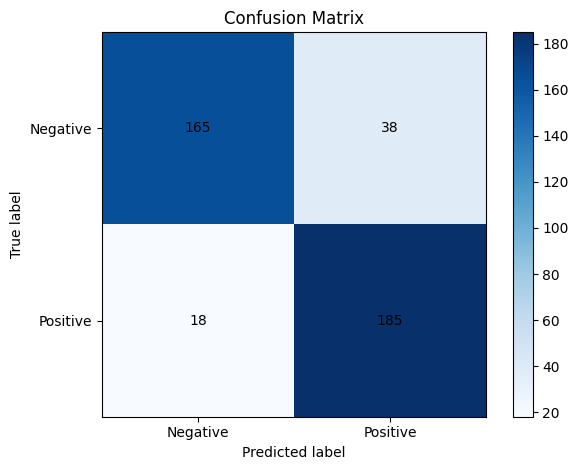

In [ ]:

# CONFUSION MATRIX
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict probabilities
y_pred_prob = model.predict(validation_dataset)

# Convert softmax probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_val_oh, axis=1)

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

print(
    "Classification Report:\n",
    classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

# Plot confusion matrix
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted label')
plt.ylabel('True label')

ticks = np.arange(2)

plt.xticks(ticks, ['Negative','Positive'])
plt.yticks(ticks, ['Negative','Positive'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.tight_layout()

plt.savefig(
    f"confusion_matrix_single_128.png",
    dpi=300,
    bbox_inches='tight'
) #save figure

plt.show()

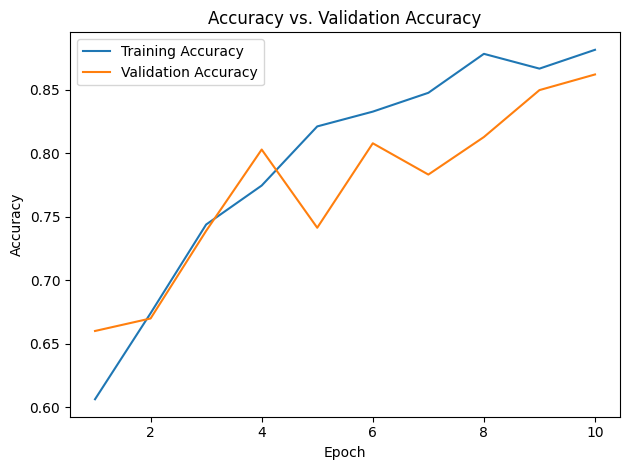

In [ ]:
# ACCURACY VS VALIDATION ACCURACY
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(accuracy) + 1)

plt.figure()

plt.plot(
    epochs,
    accuracy,
    label='Training Accuracy'
)

plt.plot(
    epochs,
    val_accuracy,
    label='Validation Accuracy'
)

plt.title('Accuracy vs. Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()

plt.savefig(
    f"accuracy_plot_segments_single_incepResV2_128.png",
    dpi=300,
    bbox_inches='tight'
) ##save figure

plt.show()

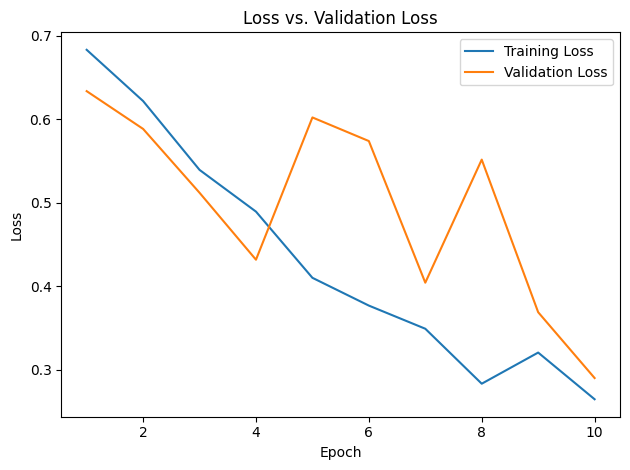

In [ ]:
# LOSS VS VALIDATION LOSS
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure()

plt.plot(
    epochs,
    loss,
    label='Training Loss'
)

plt.plot(
    epochs,
    val_loss,
    label='Validation Loss'
)

plt.title('Loss vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()

plt.savefig(
    f"loss_plot_single_128.png",
    dpi=300,
    bbox_inches='tight'
) ##save figure

plt.show()

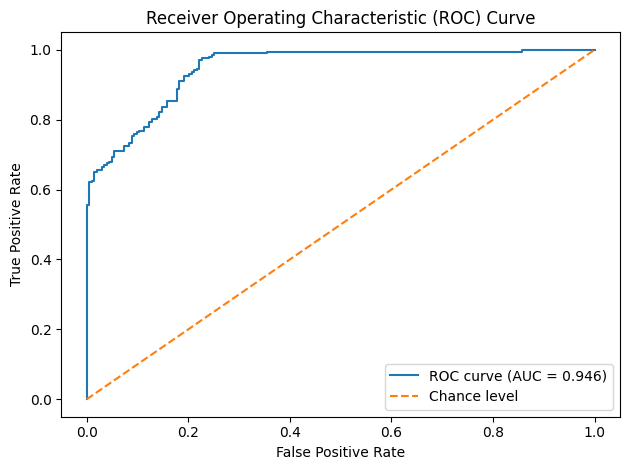

In [ ]:


# ROC CURVE
from sklearn.metrics import roc_curve, auc

# Compute ROC curve for positive class
fpr, tpr, thresholds = roc_curve(
    y_true,
    y_pred_prob[:, 1]
)

roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(
    fpr,
    tpr,
    label=f'ROC curve (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Chance level'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.tight_layout()

plt.savefig(
    f"roc_curve_segments_single_incepResV2_128.png",
    dpi=300,
    bbox_inches='tight'
) ##save figure

plt.show()

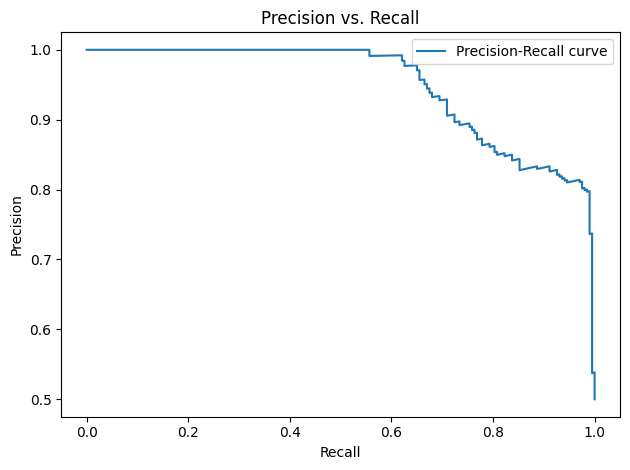


Experiment 1 Results Table: 128 Units


,Units,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,128,0.8621,0.8296,0.9113,0.8685,0.9464



Best Dense Units Based on ROC-AUC: 128


Model saved successfully!
Model saved successfully!
Model weights saved!


In [ ]:
# PRECISION-RECALL CURVE
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_true,
    y_pred_prob[:, 1]
)

plt.figure()

plt.plot(
    recall,
    precision,
    label='Precision-Recall curve'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision vs. Recall')
plt.legend()
plt.tight_layout()

plt.savefig(
    f"precision_recall_curve__incepResV2single_128.png",
    dpi=300,
    bbox_inches='tight'
) ##save figure

plt.show()

# EXPERIMENT RESULTS TABLE FOR CURRENT SEGMENT CONFIGURATION
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Calculate evaluation metrics
precision_val = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall_val = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1_val = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

accuracy_val = accuracy_score(
    y_true,
    y_pred
)

# Create results table
results_table = pd.DataFrame({
    "Units": [NUM_UNITS],
    "Accuracy": [accuracy_val],
    #"Validation Accuracy": [accuracy],
    #"Validation Loss": [loss],
    "Precision": [precision_val],
    "Recall": [recall_val],
    "F1 Score": [f1_val],
    "ROC AUC": [roc_auc]
})

# Round results for professional display
results_table = results_table.round({
    "Accuracy": 4,
    "Precision": 4,
    "Recall": 4,
    "F1 Score": 4,
    "ROC AUC": 4
})

# Display table
print(f"\nExperiment 1 Results Table: {NUM_UNITS} Units")
display(results_table)

# SAVE MODEL & WEIGHTS

print(f"\nBest Dense Units Based on ROC-AUC: {NUM_UNITS}")

model.save(
    f"Xception_model_{NUM_UNITS}.keras"
)

print("Model saved successfully!")

model.save(
    f"Xception_model_{NUM_UNITS}.h5"
)

print("Model saved successfully!")

model.save_weights(
    f"Xception_{NUM_UNITS}.weights.h5"
)

print("Model weights saved!")

In [ ]:
# Creating the destination directory
destination_folder = (
    "/content/drive/MyDrive/"
    "Xception+GRU_revised_to_loopless/"
    "Xception_weights_v2/"
)

os.makedirs(
    destination_folder,
    exist_ok=True
)

!cp /content/Xception_model_128.h5 "/content/drive/MyDrive/Xception+GRU_revised_to_loopless/Xception_weights_v2/"

!cp /content/Xception_model_128.keras "/content/drive/MyDrive/Xception+GRU_revised_to_loopless/Xception_weights_v2/"

!cp /content/Xception_128.weights.h5 "/content/drive/MyDrive/Xception+GRU_revised_to_loopless/Xception_weights_v2/"

#cjheck contents in the folder containing weights
!ls "/content/drive/MyDrive/Xception+GRU_revised_to_loopless/Xception_weights_v2/"